In [1]:
from auxiliary_functions import *

In [2]:
graph = nx.read_gexf("labeled_graph.gexf")
std_threshold = 0.5
NumberOfRandoms = 300

In [3]:
graphs = simplify_graph(graph, std_threshold)

# Generate null models for each subreddit graph
null_models = {}

for subreddit, subreddit_graph in graphs.items():
	# Create multiple randomized versions of each graph for statistical comparison
	null_models[subreddit] = [
		generate_null_model(subreddit_graph) 
		for _ in range(NumberOfRandoms)
	]

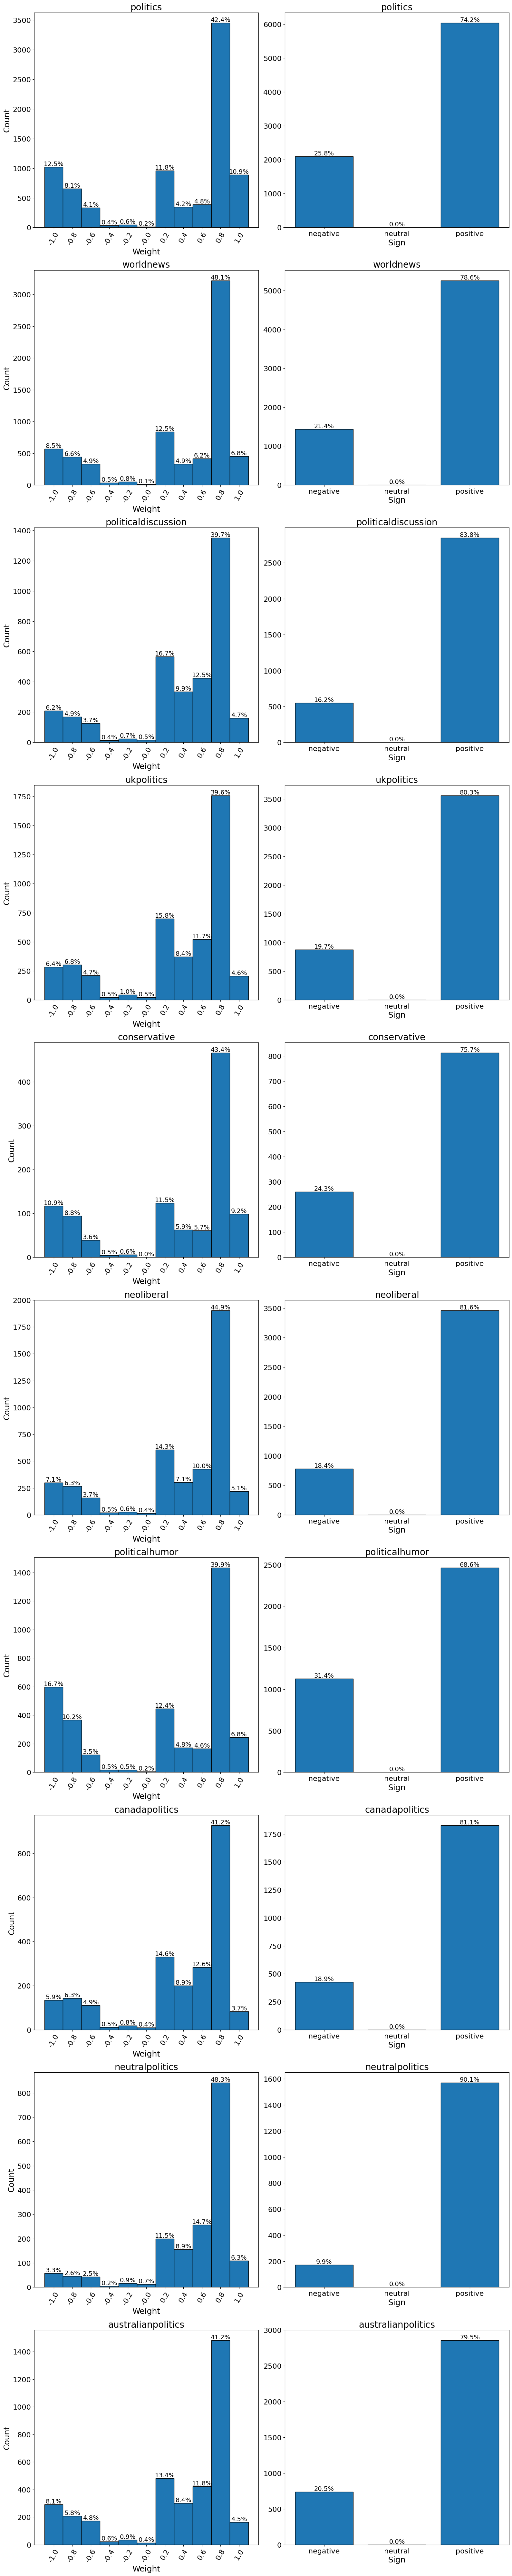

In [4]:
plot_weight_distribution(graphs)

In [5]:
triangles_graph = calculate_triangles_graph(graphs)

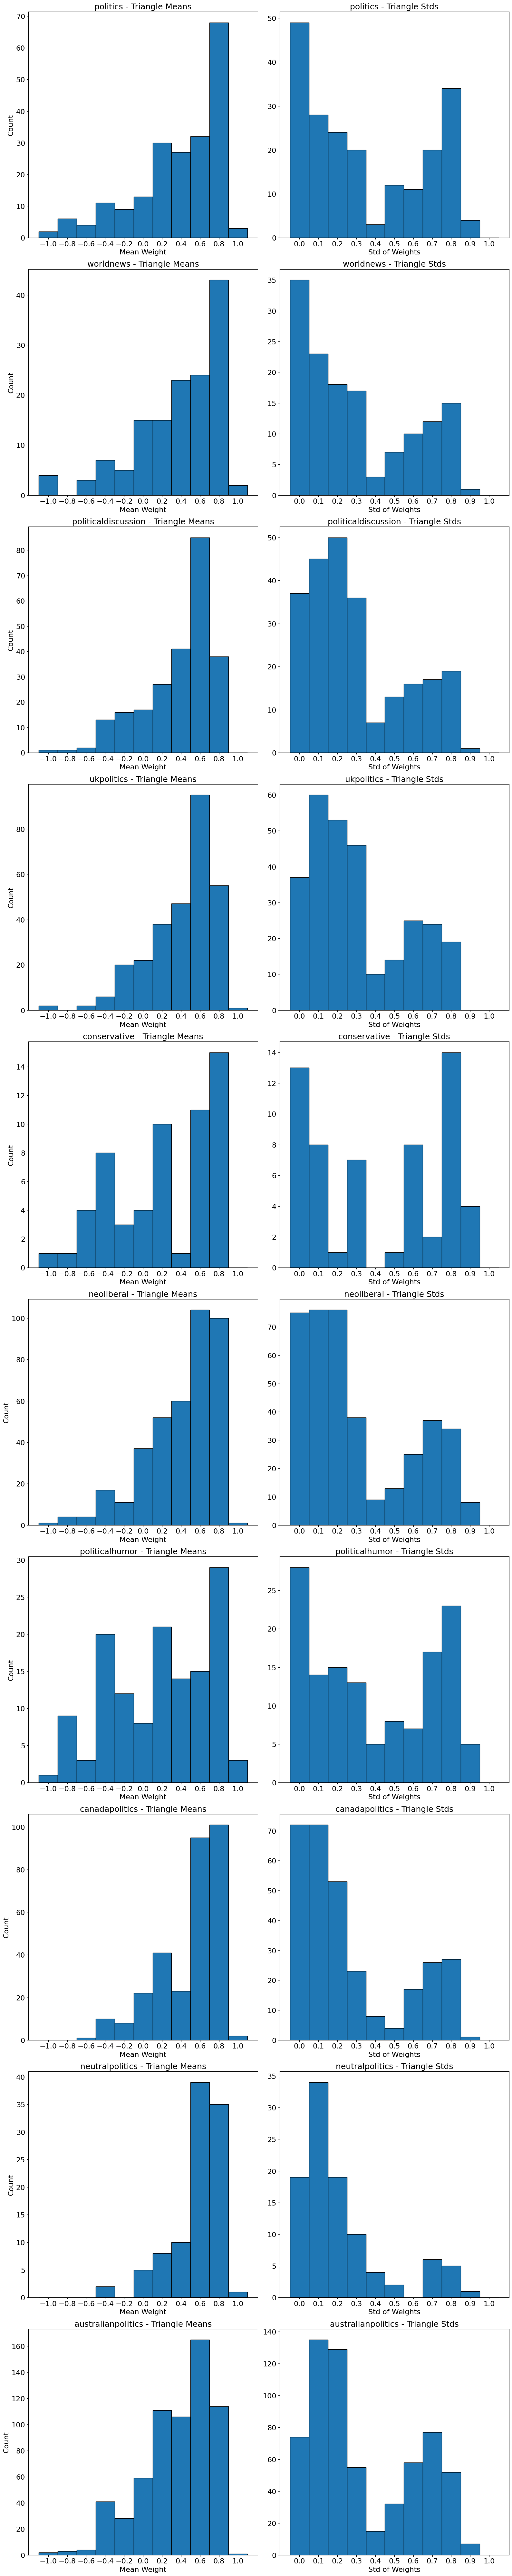

In [6]:
plot_triangle_distribution(graphs, triangles_graph)

In [7]:
df = number_of_triangles_per_type(graphs, triangles_graph)

df.to_csv('file.csv', index=True)

df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
politics,9,21,62,113
worldnews,6,10,40,85
politicaldiscussion,3,24,48,166
ukpolitics,3,24,67,194
conservative,2,14,15,27
neoliberal,6,29,100,256
politicalhumor,11,30,36,58
canadapolitics,0,16,68,219
neutralpolitics,0,3,15,82
australianpolitics,9,64,184,377


In [8]:
null_triangles = calculate_triangles_null_graph(graphs, null_models)

In [9]:
# IN DEVELOPMENT: NON_BINARY_METRIC

results_nb, distributions_nb = non_binary_metric(triangles_graph, null_triangles)
results_nb



,prod,mean,std,z-score,percentile
subreddit,,,,,
politics,0.061540,0.013591,0.024132,1.986980,98.333333
worldnews,0.089190,0.024552,0.024597,2.627864,100.000000
politicaldiscussion,0.081276,0.027236,0.014986,3.606088,100.000000
ukpolitics,0.076475,0.018866,0.013552,4.250938,100.000000
conservative,0.135232,0.013633,0.040991,2.966514,100.000000
neoliberal,0.083202,0.027793,0.013283,4.171457,100.000000
politicalhumor,0.098310,0.002761,0.030484,3.134470,99.666667
canadapolitics,0.128910,0.022566,0.015406,6.902733,100.000000
neutralpolitics,0.140683,0.084266,0.025814,2.185523,98.666667


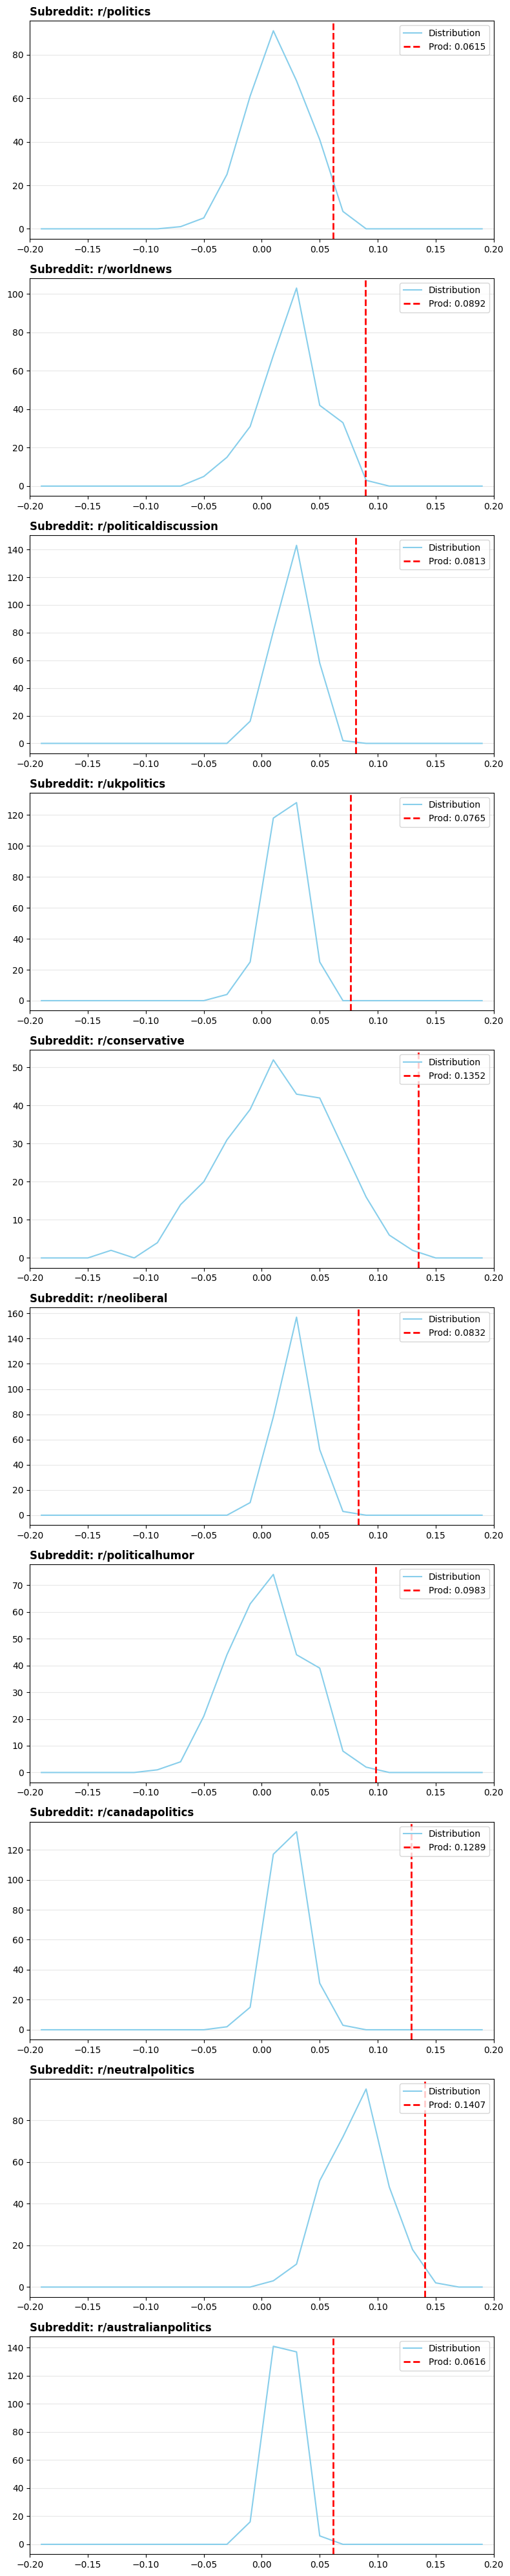

In [11]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_nb)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i, (subreddit, distribution) in enumerate(distributions_nb.items()):
    ax = axes[i]
    
    # 2. Calculate the histogram data manually to plot only the "top points"
    # We use density=True if you want the area to scale, or False for raw counts
    counts, bin_edges = np.histogram(distribution, bins=20, range=(-0.2, 0.2))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. Plot the 'top points' as a step or line plot
    ax.plot(bin_centers, counts, color='skyblue', label='Distribution')
    
    # 4. Plot and highlight the specific 'prod' value
    prod_val = results_nb.loc[subreddit, "prod"]
    ax.axvline(prod_val, color='red', linestyle='--', linewidth=2, label=f'Prod: {prod_val:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.2, 0.2)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

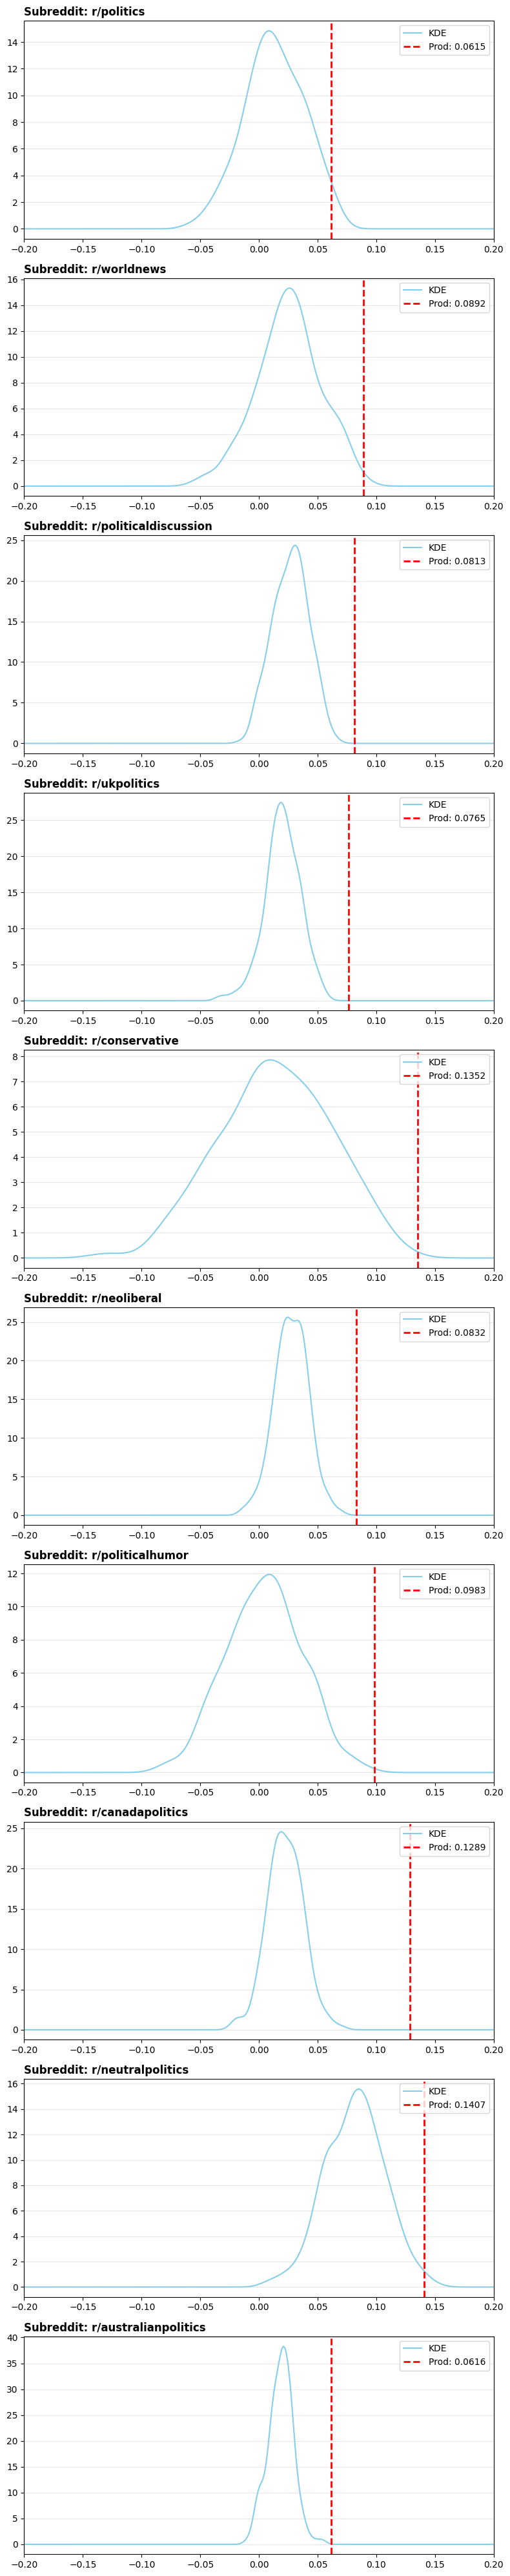

In [13]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_nb)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i, (subreddit, distribution) in enumerate(distributions_nb.items()):
    ax = axes[i]
    
    # 2. Compute a kernel density estimate instead of a raw histogram
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(distribution)
    x_vals = np.linspace(-0.2, 0.2, 300)
    y_vals = kde(x_vals)
    ax.plot(x_vals, y_vals, color='skyblue', label='KDE')
    
    # 4. Plot and highlight the specific 'prod' value
    prod_val = results_nb.loc[subreddit, "prod"]
    ax.axvline(prod_val, color='red', linestyle='--', linewidth=2, label=f'Prod: {prod_val:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.2, 0.2)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
results_b, distributions_b = calculate_balance_metrics(graphs, null_models, NumberOfRandoms)
results_b

KeyboardInterrupt: 

In [11]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


with open('distributions_b', 'r') as f:
    distributions_b = json.load(f)
    
    
list_subreddits = ["politics", "worldnews", "politicaldiscussion", "ukpolitics", "conservative", "neoliberal", "politicalhumor", "canadapolitics", "neutralpolitics", "australianpolitics"]
results_b = [0.006191, 0.021197, 0.012899, 0.016738, 0.008455, 0.017590, 0.008977, 0.011335, 0.001428, 0.014914]

results = []

for i, subreddit in enumerate(list_subreddits):
	bw = results_b[i]
	dist = distributions_b[i]
	mean = np.mean(dist)
	std = np.std(dist)
	z_score = (bw - mean) / std if std != 0 else 0
	percentile = (np.sum(np.array(dist) < bw) / len(dist)) * 100
	
	results.append({
		'subreddit': subreddit,
		'bw': bw,
		'mean': mean,
		'std': std,
		'z-score': z_score,
		'percentile': percentile
	})

df = pd.DataFrame(results).set_index('subreddit')
df

,bw,mean,std,z-score,percentile
subreddit,,,,,
politics,0.006191,0.010313,0.001167,-3.531805,0.000000
worldnews,0.021197,0.038599,0.004776,-3.643436,0.000000
politicaldiscussion,0.012899,0.023987,0.002464,-4.499059,0.000000
ukpolitics,0.016738,0.029209,0.002520,-4.949315,0.000000
conservative,0.008455,0.014586,0.002890,-2.121288,0.666667
neoliberal,0.017590,0.026864,0.002353,-3.941096,0.000000
politicalhumor,0.008977,0.021720,0.003116,-4.089688,0.000000
canadapolitics,0.011335,0.027895,0.003798,-4.359976,0.000000
neutralpolitics,0.001428,0.002190,0.000402,-1.894296,2.666667


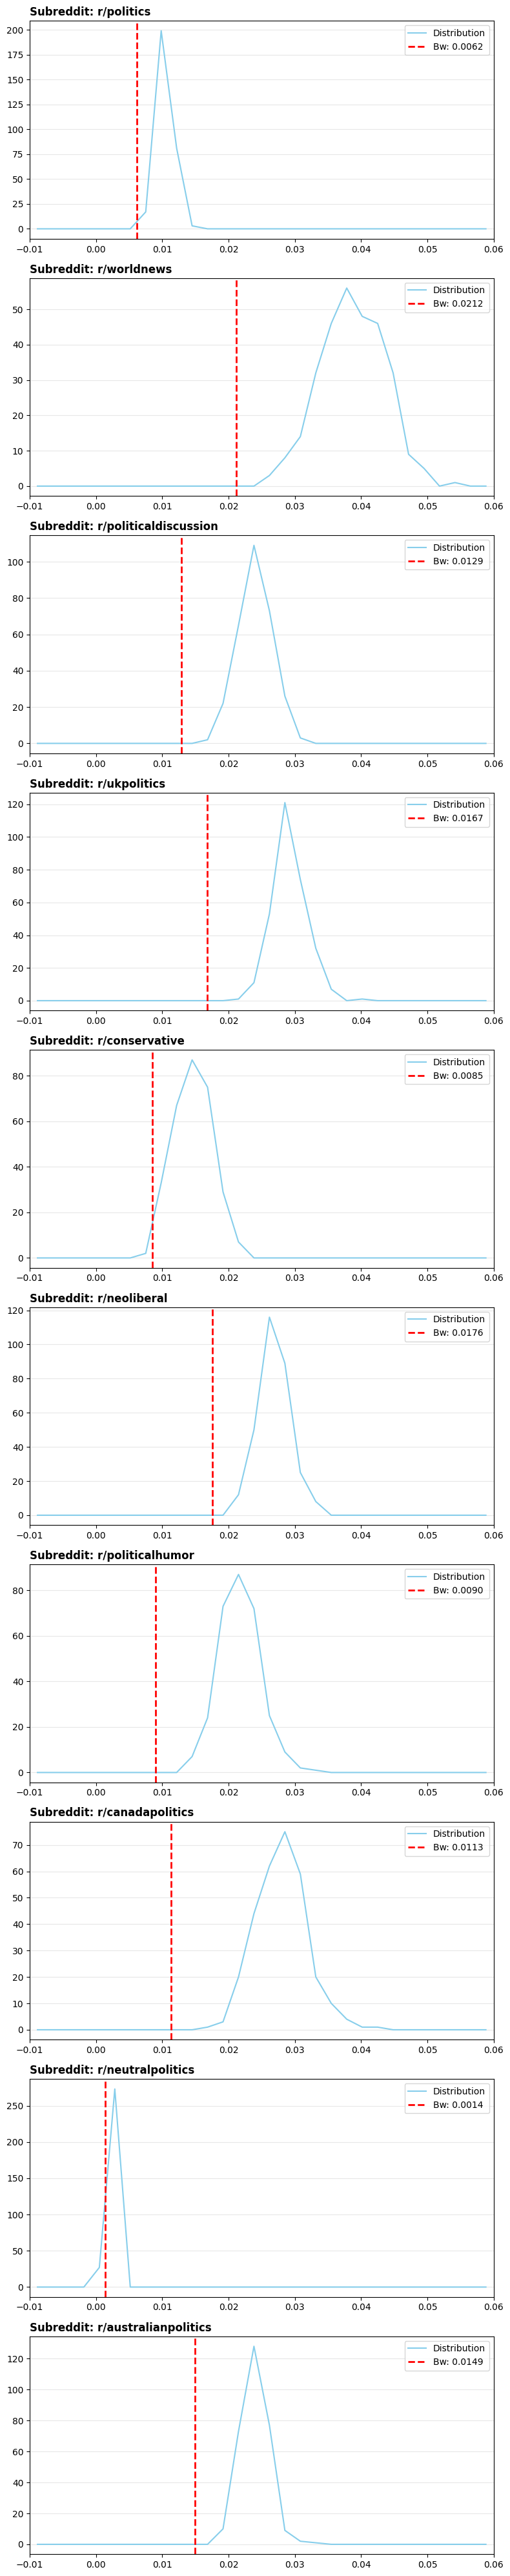

In [9]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_b)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i in range(len(distributions_b)):
    ax = axes[i]
    subreddit = list_subreddits[i]
    distribution = distributions_b[i]
    
    # 2. Calculate the histogram data manually to plot only the "top points"
    # We use density=True if you want the area to scale, or False for raw counts
    counts, bin_edges = np.histogram(distribution, bins=30, range=(-0.01, 0.06))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. Plot the 'top points' as a step or line plot
    ax.plot(bin_centers, counts, color='skyblue', label='Distribution')
    
    # 4. Plot and highlight the specific 'prod' value
    b_w = results_b[i]
    ax.axvline(b_w, color='red', linestyle='--', linewidth=2, label=f'Bw: {b_w:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.01, 0.06)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

[0.01182136648741125, 0.011937632256650735, 0.009711619898900655, 0.010218658028921088, 0.009667534100483353, 0.009082463932821753, 0.009327706570966331, 0.008729806463465727, 0.009487829085454084, 0.00913987067837264, 0.01096422713361519, 0.011443960996639316, 0.009119495046309453, 0.011441757788368324, 0.009185318635094964, 0.010579223285928707, 0.009510123306855491, 0.010878269500687546, 0.009796359703315478, 0.009170876300114863, 0.011046854484180683, 0.010120856971523292, 0.009109358604746778, 0.010236375465607647, 0.009186917781211643, 0.010363127248595255, 0.008598634245389467, 0.010036519933289773, 0.008026247016635632, 0.011285001818288953, 0.007616560145074801, 0.00788568401248706, 0.008591959460158616, 0.010855536776336078, 0.008448093420551932, 0.010866267075136505, 0.008986791157622135, 0.010971011404323766, 0.00892032669241753, 0.008209568886282256, 0.01044820575715134, 0.009609049038044212, 0.010222935474094336, 0.009357366823375846, 0.010114722309201438, 0.0098830928775

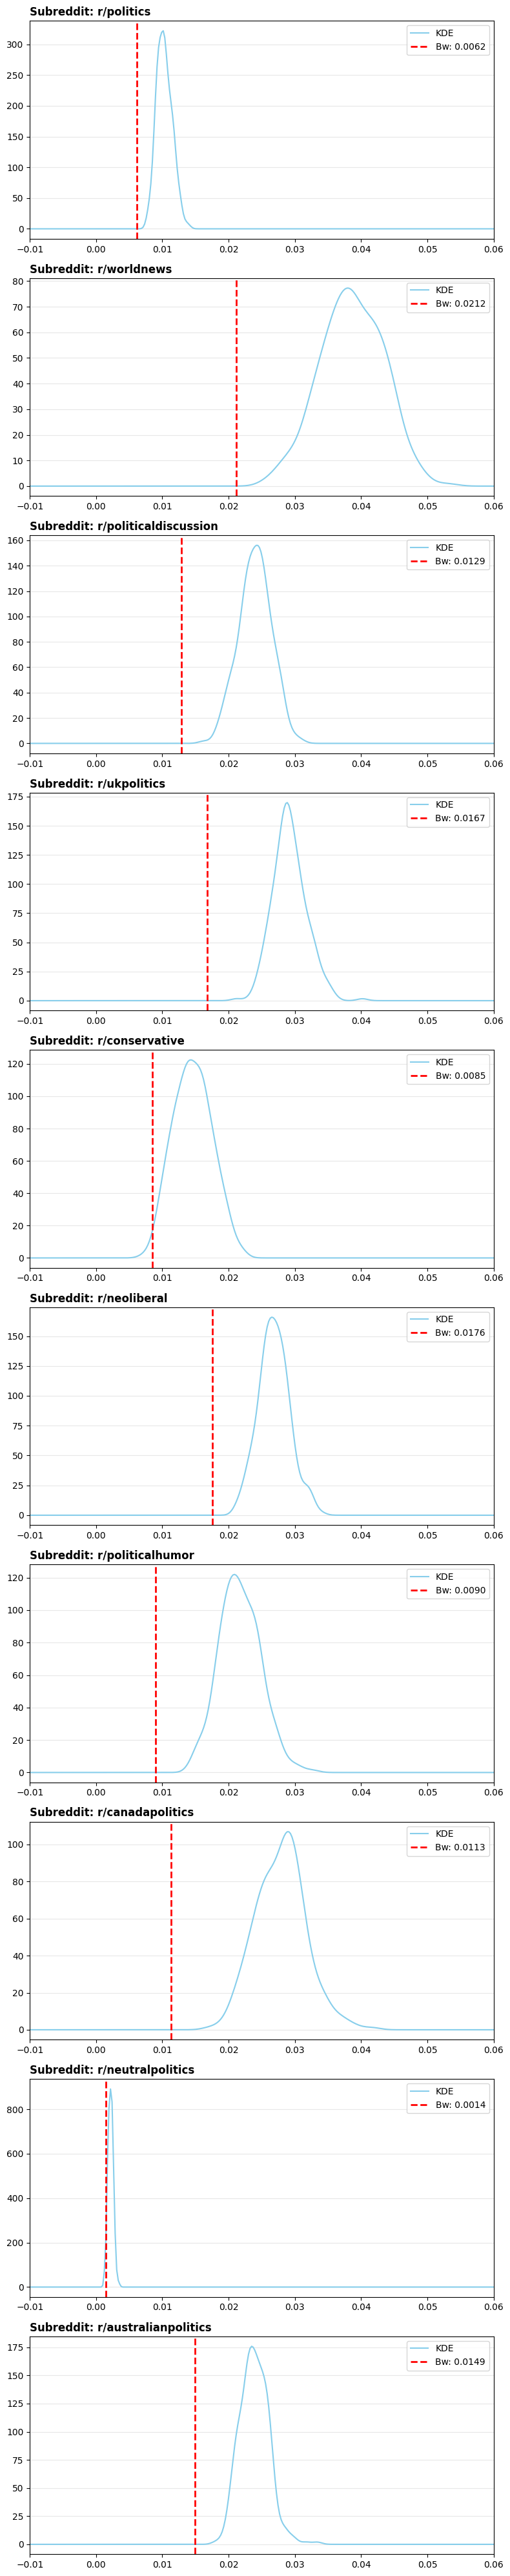

In [ ]:
# 1. Create a figure with a subplot for each subreddit
num_subs = len(distributions_b)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
    axes = [axes]

for i in range(len(distributions_b)):
    ax = axes[i]
    subreddit = list_subreddits[i]
    distribution = distributions_b[i]
    
    # 2. Compute a kernel density estimate instead of a raw histogram
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(distribution)
    x_vals = np.linspace(-0.01, 0.06, 300)
    y_vals = kde(x_vals)
    ax.plot(x_vals, y_vals, color='skyblue', label='KDE')

    
    # 3. Plot and highlight the specific 'prod' value
    b_w = results_b[i]
    ax.axvline(b_w, color='red', linestyle='--', linewidth=2, label=f'Bw: {b_w:.4f}')
    
    # Formatting
    ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
    ax.set_xlim(-0.01, 0.06)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
D_distribution = {}
results = []

for idx, (subreddit, triangle_list) in enumerate(triangles_graph.items()):
	# Process real data: compute signed geometric means
	all_triangles_dict = defaultdict(int)
	for triangle in triangle_list:
		val = geo_abs(triangle)
		all_triangles_dict[val] += 1
	
	vals_all, cum_all = prepare_cumulative(all_triangles_dict)
	# Process null models
	null_all_dicts = []
 
	for null_model in null_triangles[subreddit]:
		null_all = defaultdict(int)
		for triangle in null_model:
			val = geo_abs(triangle)
			null_all[val] += 1
		null_all_dicts.append(null_all)
  
	vals_all_null, cum_all_null = average_null_models(null_all_dicts)
 
	D_distribution[subreddit] = []
	for null_all in null_all_dicts:
		vals_null, cum_null = prepare_cumulative(null_all)
		D_null_vs_avg = kolmogorov(vals_null, cum_null, vals_all_null, cum_all_null)
		D_distribution[subreddit].append(D_null_vs_avg)
 
	D = kolmogorov(vals_all, cum_all, vals_all_null, cum_all_null)
 
	mean = np.mean(D_distribution[subreddit])
 
	std = np.std(D_distribution[subreddit])

	
	percentile = (np.sum(np.array(D_distribution[subreddit]) < D) / len(D_distribution[subreddit])) * 100

	results.append({
		'subreddit': subreddit,
		'D': D,
		"mean": mean, 
		"std": std,
		"z-score": (D - mean) / std,
		"percentile": percentile
	})
 
results_df = pd.DataFrame(results).set_index("subreddit")

results_df

,D,mean,std,z-score,percentile
subreddit,,,,,
politics,22.290000,12.124556,3.691933,2.753420,99.000000
worldnews,15.863333,10.100856,3.346542,1.721920,92.666667
politicaldiscussion,39.543333,13.517367,4.244486,6.131713,100.000000
ukpolitics,42.900000,14.297056,4.311883,6.633515,100.000000
conservative,13.400000,6.518556,1.988503,3.460616,100.000000
neoliberal,49.860000,17.300444,5.346488,6.089896,100.000000
politicalhumor,20.663333,9.995344,3.090351,3.452031,99.666667
canadapolitics,78.816667,16.990456,5.396942,11.455785,100.000000
neutralpolitics,15.110000,9.176522,2.953575,2.008914,96.666667


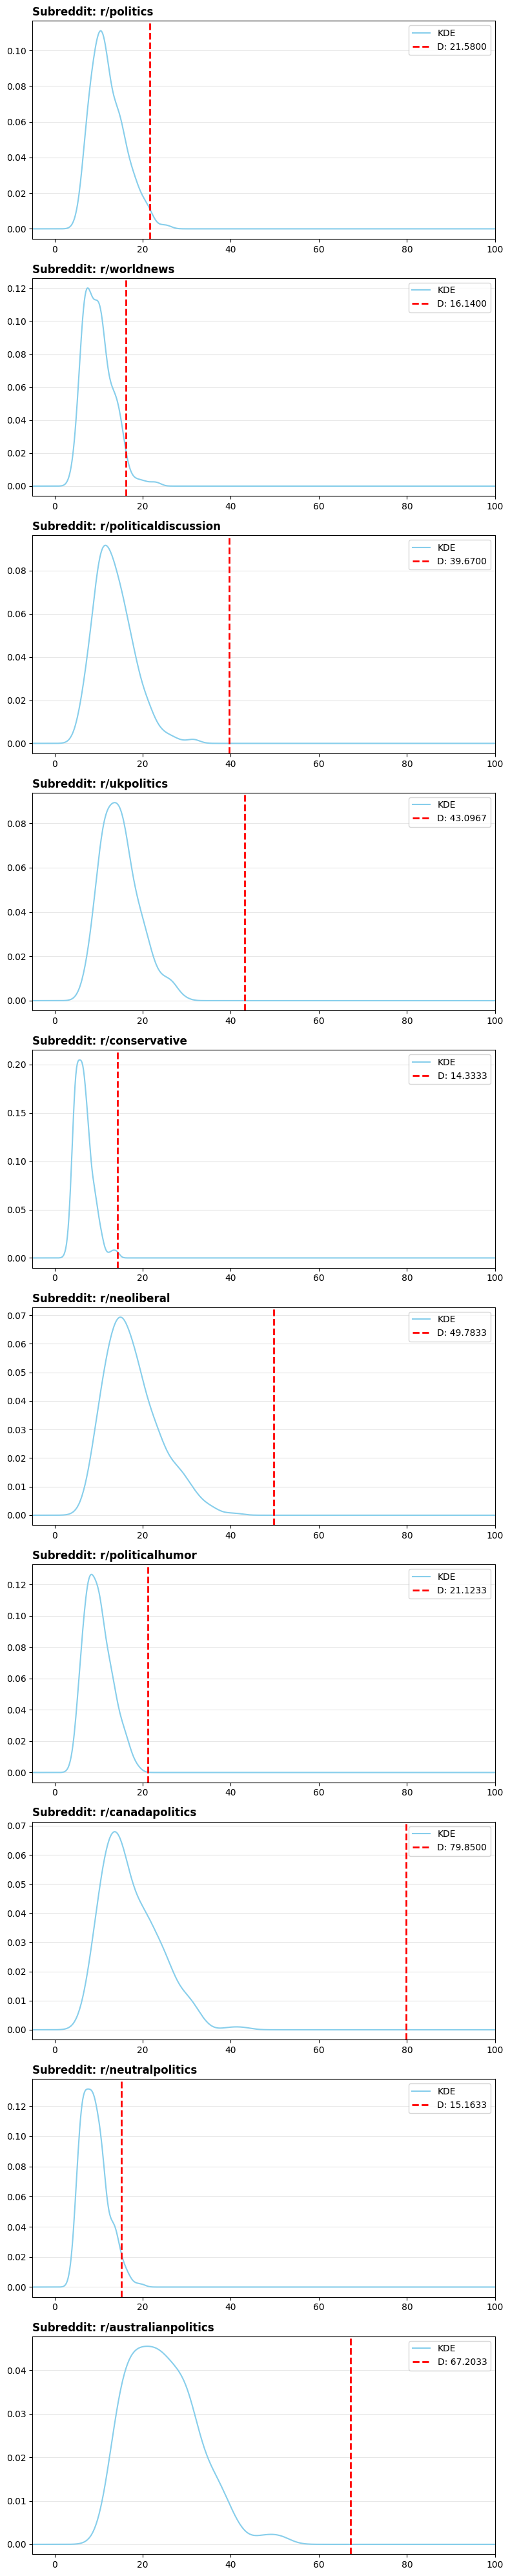

In [9]:
from scipy.stats import gaussian_kde

# 1. Create a figure with a subplot for each subreddit
num_subs = len(D_distribution)
fig, axes = plt.subplots(num_subs, 1, figsize=(8, 4 * num_subs))

# Handle the case where there's only 1 subreddit (axes wouldn't be a list)
if num_subs == 1:
	axes = [axes]

for i, (subreddit, distribution) in enumerate(D_distribution.items()):
	ax = axes[i]
	
	# 2. Compute a kernel density estimate instead of a raw histogram
	kde = gaussian_kde(distribution)
	x_vals = np.linspace(-5, 100, 600)
	y_vals = kde(x_vals)
	ax.plot(x_vals, y_vals, color='skyblue', label='KDE')

	# 3. Plot and highlight the specific 'D' value
	d_val = results_df.loc[subreddit, 'D']
	ax.axvline(d_val, color='red', linestyle='--', linewidth=2, label=f'D: {d_val:.4f}')
	
	# Formatting
	ax.set_title(f"Subreddit: r/{subreddit}", loc='left', fontweight='bold')
	ax.set_xlim(-5, 100)
	ax.legend(loc='upper right')
	ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
kolmogorov_smirnov(triangles_graph, null_triangles)